In [ ]:
import warnings
warnings.filterwarnings("ignore")
#import the necessary libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
from sklearn.metrics import accuracy_score,f1_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
#set the backgroung style sheet
sns.set_style("whitegrid")

In [ ]:
#load the csv file in a dataframe using read_csv function
df = pd.read_csv('/content/Drug_Consumption_Quantified.csv',encoding="latin-1")
copy_df = df.copy()        #make a copy of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1884 non-null   int64  
 1   Age        1884 non-null   float64
 2   Gender     1884 non-null   float64
 3   Education  1884 non-null   float64
 4   Country    1884 non-null   float64
 5   Ethnicity  1884 non-null   float64
 6   Nscore     1884 non-null   float64
 7   Escore     1884 non-null   float64
 8   Oscore     1884 non-null   float64
 9   AScore     1884 non-null   float64
 10  Cscore     1884 non-null   float64
 11  Impulsive  1884 non-null   float64
 12  SS         1884 non-null   float64
 13  Alcohol    1884 non-null   object 
 14  Amphet     1884 non-null   object 
 15  Amyl       1884 non-null   object 
 16  Benzos     1884 non-null   object 
 17  Caff       1884 non-null   object 
 18  Cannabis   1884 non-null   object 
 19  Choc       1884 non-null   object 
 20  Coke    

In [ ]:
df.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,AScore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
1,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
2,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
3,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
4,6,2.59171,0.48246,-1.22751,0.24923,-0.31685,-0.67825,-0.30033,-1.55521,2.03972,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL6,CL0,CL0


In [ ]:
df.isnull().sum()

,0
ID,0
Age,0
Gender,0
Education,0
Country,0
Ethnicity,0
Nscore,0
Escore,0
Oscore,0
AScore,0


In [ ]:
#load the csv file in a dataframe using read_csv function
df1 = pd.read_csv('/content/drug_raw_consumption.csv',encoding="latin-1")
copy_df1 = df1.copy()        #make a copy of the dataframe
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1938 non-null   int64  
 1   Age        1938 non-null   object 
 2   Gender     1938 non-null   object 
 3   Education  1938 non-null   object 
 4   Country    1938 non-null   object 
 5   Ethnicity  1938 non-null   object 
 6   Nscore     1938 non-null   float64
 7   Escore     1938 non-null   float64
 8   Oscore     1938 non-null   float64
 9   AScore     1938 non-null   float64
 10  Cscore     1938 non-null   float64
 11  Impulsive  1938 non-null   float64
 12  SS         1938 non-null   object 
 13  Alcohol    1938 non-null   object 
 14  Caff       1938 non-null   object 
 15  Choc       1938 non-null   object 
 16  Coke       1938 non-null   object 
 17  Ecstasy    1938 non-null   object 
 18  Heroin     1938 non-null   object 
 19  LSD        1938 non-null   object 
 20  Mushroom

In [ ]:
df3 = [df,df1]
data = pd.concat(df3)
display (data)

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,AScore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
1,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
2,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
3,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
4,6,2.59171,0.48246,-1.22751,0.24923,-0.31685,-0.67825,-0.30033,-1.55521,2.03972,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL6,CL0,CL0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,1934,35-44,F,"Some college or university, no certificate or ...",UK,White,0.31287,-1.92173,-1.42424,-0.76096,...,CL6,CL2,NaN,NaN,CL6,NaN,CL0,CL0,NaN,NaN
1934,1935,35-44,F,Masters degree,UK,White,0.91093,-0.57545,0.29338,-0.60633,...,CL6,CL0,NaN,NaN,CL5,NaN,CL0,CL0,NaN,NaN
1935,1936,35-44,F,Masters degree,UK,White,1.37297,0.32197,0.72330,0.28783,...,CL6,CL3,NaN,NaN,CL6,NaN,CL0,CL0,NaN,NaN
1936,1937,35-44,M,Professional certificate/ diploma,Canada,White,0.41667,-0.43999,0.72330,0.28783,...,CL6,CL1,NaN,NaN,CL0,NaN,CL0,CL0,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3822 entries, 0 to 1937
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         3822 non-null   int64  
 1   Age        3822 non-null   object 
 2   Gender     3822 non-null   object 
 3   Education  3822 non-null   object 
 4   Country    3822 non-null   object 
 5   Ethnicity  3822 non-null   object 
 6   Nscore     3822 non-null   float64
 7   Escore     3822 non-null   float64
 8   Oscore     3822 non-null   float64
 9   AScore     3822 non-null   float64
 10  Cscore     3822 non-null   float64
 11  Impulsive  3822 non-null   float64
 12  SS         3822 non-null   object 
 13  Alcohol    3822 non-null   object 
 14  Amphet     1884 non-null   object 
 15  Amyl       1884 non-null   object 
 16  Benzos     3822 non-null   object 
 17  Caff       3822 non-null   object 
 18  Cannabis   1884 non-null   object 
 19  Choc       3822 non-null   object 
 20  Coke       38

#Data Preprocessing

In [ ]:
data.drop('ID',axis=1,inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3822 entries, 0 to 1937
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        3822 non-null   object 
 1   Gender     3822 non-null   object 
 2   Education  3822 non-null   object 
 3   Country    3822 non-null   object 
 4   Ethnicity  3822 non-null   object 
 5   Nscore     3822 non-null   float64
 6   Escore     3822 non-null   float64
 7   Oscore     3822 non-null   float64
 8   AScore     3822 non-null   float64
 9   Cscore     3822 non-null   float64
 10  Impulsive  3822 non-null   float64
 11  SS         3822 non-null   object 
 12  Alcohol    3822 non-null   object 
 13  Amphet     1884 non-null   object 
 14  Amyl       1884 non-null   object 
 15  Benzos     3822 non-null   object 
 16  Caff       3822 non-null   object 
 17  Cannabis   1884 non-null   object 
 18  Choc       3822 non-null   object 
 19  Coke       3822 non-null   object 
 20  Crack      18

In [ ]:
data.isnull().sum()

,0
Age,0
Gender,0
Education,0
Country,0
Ethnicity,0
Nscore,0
Escore,0
Oscore,0
AScore,0
Cscore,0


In [ ]:
data.drop('VSA',axis=1,inplace=True)

In [ ]:
data.drop('Semer',axis=1,inplace=True)

In [ ]:
data.drop('Meth',axis=1,inplace=True)

In [ ]:
data.drop('Legalh',axis=1,inplace=True)

In [ ]:
data.drop('Ketamine',axis=1,inplace=True)

In [ ]:
data.drop('Crack',axis=1,inplace=True)

In [ ]:
data.drop('Cannabis',axis=1,inplace=True)

In [ ]:
data.drop('Amyl',axis=1,inplace=True)

In [ ]:
data.drop('Amphet',axis=1,inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3822 entries, 0 to 1937
Data columns (total 22 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        3822 non-null   object 
 1   Gender     3822 non-null   object 
 2   Education  3822 non-null   object 
 3   Country    3822 non-null   object 
 4   Ethnicity  3822 non-null   object 
 5   Nscore     3822 non-null   float64
 6   Escore     3822 non-null   float64
 7   Oscore     3822 non-null   float64
 8   AScore     3822 non-null   float64
 9   Cscore     3822 non-null   float64
 10  Impulsive  3822 non-null   float64
 11  SS         3822 non-null   object 
 12  Alcohol    3822 non-null   object 
 13  Benzos     3822 non-null   object 
 14  Caff       3822 non-null   object 
 15  Choc       3822 non-null   object 
 16  Coke       3822 non-null   object 
 17  Ecstasy    3822 non-null   object 
 18  Heroin     3822 non-null   object 
 19  LSD        3822 non-null   object 
 20  Mushrooms  38

In [ ]:
data.replace(to_replace=['M',  'F'],
             value=['0','1'],inplace=True)


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [ ]:
data['Country'] = data['Country'].astype(str)
data['Ethnicity'] = data['Ethnicity'].astype(str)
data['SS'] = data['SS'].astype(str)


In [ ]:

enc = LabelEncoder()
data['Country'] = enc.fit_transform(data['Country'])
data['Ethnicity'] = enc.fit_transform(data['Ethnicity'])
data['SS'] = enc.fit_transform(data['SS'])
data['Alcohol'] = enc.fit_transform(data['Alcohol'])
data['Caff'] = enc.fit_transform(data['Caff'])
data['Choc'] = enc.fit_transform(data['Choc'])
data['Choc'] = enc.fit_transform(data['Choc'])
data['Coke'] = enc.fit_transform(data['Coke'])
data['Ecstasy'] = enc.fit_transform(data['Ecstasy'])
data['Heroin'] = enc.fit_transform(data['Heroin'])
data['LSD'] = enc.fit_transform(data['LSD'])
data['Mushrooms'] = enc.fit_transform(data['Mushrooms'])
data['Nicotine'] = enc.fit_transform(data['Nicotine'])
data['Benzos'] = enc.fit_transform(data['Benzos'])

In [ ]:
data.head()

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,AScore,Cscore,...,Alcohol,Benzos,Caff,Choc,Coke,Ecstasy,Heroin,LSD,Mushrooms,Nicotine
0,-0.07854,-0.48246,1.98437,6,1,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,5,0,6,6,3,4,0,2,0,4
1,0.49788,-0.48246,-0.05921,6,1,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,6,0,6,4,0,0,0,0,1,0
2,-0.95197,0.48246,1.16365,6,1,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,4,3,5,4,2,0,0,0,0,2
3,0.49788,0.48246,1.98437,6,1,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,4,0,6,6,0,1,0,0,2,2
4,2.59171,0.48246,-1.22751,5,1,-0.67825,-0.30033,-1.55521,2.03972,1.63088,...,2,0,6,4,0,0,0,0,0,6


In [ ]:
data.drop('Education',axis=1,inplace=True)

In [ ]:
data.describe()

,Country,Ethnicity,Nscore,Escore,Oscore,AScore,Cscore,Impulsive,SS,Alcohol,Benzos,Caff,Choc,Coke,Ecstasy,Heroin,LSD,Mushrooms,Nicotine
count,3822.000000,3822.000000,3822.000000,3822.000000,3822.000000,3822.000000,3822.000000,3822.000000,3822.000000,3822.000000,3822.000000,3822.000000,3822.000000,3822.000000,3822.00000,3822.000000,3822.000000,3822.000000,3822.000000
mean,5.830717,4.677917,-0.003656,-0.001892,-0.007940,-0.001889,0.000439,0.000653,5.923600,4.636578,1.451858,5.410780,5.040031,1.155154,1.37572,0.384877,1.122711,1.181580,3.156463
std,1.823218,3.494135,0.997014,0.995312,0.998243,0.996064,0.995446,0.957507,3.269284,1.329728,1.862216,1.264443,1.219109,1.512834,1.71851,1.044025,1.569422,1.467789,2.426110
min,0.000000,0.000000,-3.464360,-3.273930,-3.273930,-3.464360,-3.464360,-2.555240,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,1.000000,-0.678250,-0.695090,-0.717270,-0.606330,-0.652530,-0.711260,3.000000,4.000000,0.000000,5.000000,5.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000
50%,7.000000,8.000000,0.042570,0.003320,-0.019280,-0.017290,-0.006650,-0.217120,7.000000,5.000000,0.000000,6.000000,5.000000,0.000000,0.00000,0.000000,0.000000,0.000000,3.000000
75%,7.000000,8.000000,0.629670,0.637790,0.723300,0.590420,0.584890,0.529750,9.000000,6.000000,3.000000,6.000000,6.000000,2.000000,3.00000,0.000000,2.000000,2.000000,6.000000
max,10.000000,11.000000,3.273930,3.273930,2.901610,3.464360,3.464360,2.901610,11.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.000000


In [ ]:
# Combine cocaine and crack cocaine usage into one feature
cocaine_df = data.copy()
cocaine_df['coke_user'] = cocaine_df['Coke'].apply(lambda x: 0.5 if x not in [0,1] else 0)
cocaine_df['crack_user'] = cocaine_df['Coke'].apply(lambda x: 0.5 if x not in [0,1] else 0)
cocaine_df['both_user'] = cocaine_df[['coke_user', 'crack_user']].iloc[:].sum(axis=1)
cocaine_df['Cocaine_User'] = cocaine_df['both_user'].apply(lambda x: 1 if x > 0 else 0)
cocaine_df = cocaine_df.drop(['coke_user', 'crack_user', 'both_user' ], axis=1)

In [ ]:
'''meth_df = data.copy()
meth_df['Meth_User'] = meth_df['Meth'].apply(lambda x: 1 if x not in [0,1] else 0)
meth_df = meth_df.drop(['Meth'], axis=1)'''

"meth_df = data.copy()\nmeth_df['Meth_User'] = meth_df['Meth'].apply(lambda x: 1 if x not in [0,1] else 0)\nmeth_df = meth_df.drop(['Meth'], axis=1)"

In [ ]:
heroin_df = data.copy()
heroin_df['Heroin_User'] = heroin_df['Heroin'].apply(lambda x: 1 if x not in [0,1] else 0)
heroin_df = heroin_df.drop(['Heroin'], axis=1)

In [ ]:
nic_df = data.copy()
nic_df['Nicotine_User'] = nic_df['Nicotine'].apply(lambda x: 1 if x not in [0,1] else 0)
nic_df = nic_df.drop(['Nicotine'], axis=1)

In [ ]:
benzos_df = data.copy()
benzos_df['Benzos_User'] = benzos_df['Benzos'].apply(lambda x: 1 if x not in [0,1] else 0)
benzos_df = benzos_df.drop(['Benzos'], axis = 1)

In [ ]:
alcohol_df = data.copy()
alcohol_df['Alcohol_User'] = alcohol_df['Alcohol'].apply(lambda x: 1 if x not in [0,1] else 0)
alcohol_df = alcohol_df.drop(['Alcohol'], axis = 1)

In [ ]:
LSD_df = data.copy()
LSD_df['LSD_User'] = LSD_df['LSD'].apply(lambda x: 1 if x not in [0,1] else 0)
LSD_df = LSD_df.drop(['LSD'], axis = 1)

In [ ]:
Mushrooms_df = data.copy()
Mushrooms_df['Mushrooms_User'] = Mushrooms_df['Mushrooms'].apply(lambda x: 1 if x not in [0,1] else 0)
Mushrooms_df = Mushrooms_df.drop(['Mushrooms'], axis = 1)

In [ ]:
Ecstasy_df = data.copy()
Ecstasy_df['Ecstasy_User'] = Ecstasy_df['Ecstasy'].apply(lambda x: 1 if x not in [0,1] else 0)
Ecstasy_df = Ecstasy_df.drop(['Ecstasy'], axis = 1)

In [ ]:
Caff_df = data.copy()
Caff_df['Caff_User'] = Caff_df['Caff'].apply(lambda x: 1 if x not in [0,1] else 0)
Caff_df = Caff_df.drop(['Caff'], axis = 1)

In [ ]:
Choc_df = data.copy()
Choc_df['Choc_User'] = Choc_df['Choc'].apply(lambda x: 1 if x not in [0,1] else 0)
Choc_df = Choc_df.drop(['Choc'], axis = 1)

In [ ]:
data.shape

(3822, 21)

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
def preprocessing_inputs(data, column):
    data = data.copy()

    # Split df into X and y

    X = data.drop(column, axis=1)
    y = data[column]
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

    # Scale X
    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train = pd.DataFrame(scaler.transform(X_train),
                           index=X_train.index,
                           columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test),
                          index=X_test.index,
                          columns=X_test.columns)

    return X_train, X_test, y_train, y_test

In [ ]:
def plot_confusion_matrix(y,y_predict):
    #Function to easily plot confusion matrix
    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax, fmt='g', cmap='Blues');
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix');
    ax.xaxis.set_ticklabels(['non-user', 'user']); ax.yaxis.set_ticklabels(['non-user', 'user'])

In [ ]:

def preprocessing_inputs(df, target_column):
    # Your preprocessing steps here...

    # Assuming X and y are the preprocessed features and target
    X_train, X_test, y_train, y_test = train_test_split(df.drop(target_column, axis=1), df[target_column], test_size=0.2, random_state=42)

    # More preprocessing if needed...

    return X_train, X_test, y_train, y_test





# Alcohol user

In [ ]:
X_train, X_test, y_train, y_test = preprocessing_inputs(alcohol_df, 'Alcohol_User')

In [ ]:
print('Train set:', X_train.shape, y_train.shape)
print('Test set:', X_test.shape, y_test.shape)

Train set: (3057, 20) (3057,)
Test set: (765, 20) (765,)


In [ ]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(),
    'Ridge Classifier': RidgeClassifier(),
    'Support Vector Machines': SVC(),
    'Random Forest Classifier': RandomForestClassifier(),
    'AdaBoost Classifier': AdaBoostClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier()

}

In [ ]:
import pandas as pd

# Assuming your DataFrame is named X_train and contains a column named 'age'
# If the actual column name is different, replace 'age' with the correct name
X_train['Age'] = X_train['Age'].apply(lambda x: int(x.split('-')[0]) if isinstance(x, str) and '-' in x else int(x[:-1]) if isinstance(x, str) and x.endswith('+') else int(x) if isinstance(x, (int, float)) else None)

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(name + ' trained.')

Logistic Regression trained.
Ridge Classifier trained.
Support Vector Machines trained.
Random Forest Classifier trained.
AdaBoost Classifier trained.
Decision Tree Classifier trained.


In [ ]:
import pandas as pd

# Assuming your DataFrame is named X_test and contains a column named 'age'
# If the actual column name is different, replace 'age' with the correct name

# Convert age ranges to the average of the range
X_test['Age'] = X_test['Age'].apply(lambda x: (int(x.split('-')[0]) + int(x.split('-')[1])) / 2 if isinstance(x, str) and '-' in x else float(x[:-1]) if isinstance(x, str) and x.endswith('+') else x)

# Now, you can proceed with making predictions
for name, model in models.items():
    yhat = model.predict(X_test)
    acc = accuracy_score(y_test, yhat)
    print(name + ' Accuracy: {:.2%}'.format(acc))

Logistic Regression Accuracy: 96.08%
Ridge Classifier Accuracy: 96.08%
Support Vector Machines Accuracy: 96.08%
Random Forest Classifier Accuracy: 96.86%
AdaBoost Classifier Accuracy: 95.95%
Decision Tree Classifier Accuracy: 96.08%


In [ ]:
print('                  F1 SCORES')
for name, model in models.items():
    yhat = model.predict(X_test)
    f1 = f1_score(y_test, yhat, pos_label=1)
    print(name + ' F1-Score: {:.5}'.format(f1))

                  F1 SCORES
Logistic Regression F1-Score: 0.98
Ridge Classifier F1-Score: 0.98
Support Vector Machines F1-Score: 0.98
Random Forest Classifier F1-Score: 0.98394
AdaBoost Classifier F1-Score: 0.97932
Decision Tree Classifier F1-Score: 0.97959


In [ ]:
print('                  Recall')
for name, model in models.items():
    yhat = model.predict(X_test)
    recall = recall_score(y_test, yhat, pos_label=1)
    print(name + ' Recall: {:.5}'.format(recall))

                  Recall
Logistic Regression Recall: 1.0
Ridge Classifier Recall: 1.0
Support Vector Machines Recall: 1.0
Random Forest Classifier Recall: 1.0
AdaBoost Classifier Recall: 0.99864
Decision Tree Classifier Recall: 0.97959


In [ ]:
print('                  Precison')
for name, model in models.items():
    yhat = model.predict(X_test)
    precision = precision_score(y_test, yhat, pos_label=1)
    print(name + ' Precison: {:.5}'.format(precision))

                  Precison
Logistic Regression Precison: 0.96078
Ridge Classifier Precison: 0.96078
Support Vector Machines Precison: 0.96078
Random Forest Classifier Precison: 0.96838
AdaBoost Classifier Precison: 0.96073
Decision Tree Classifier Precison: 0.97959


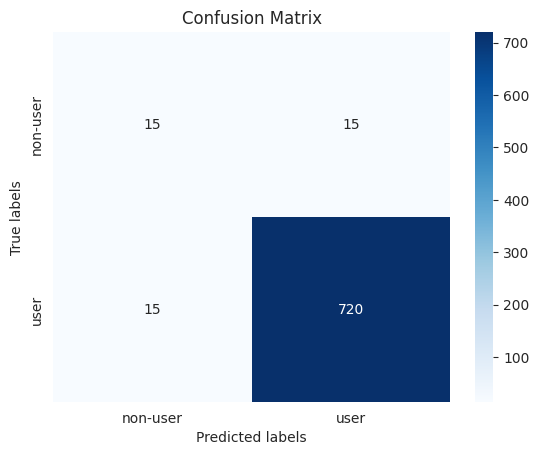

In [ ]:
plot_confusion_matrix(y_test, yhat)

In [ ]:
# Define models and extended hyperparameter grids
models = {
    'Logistic Regression': (LogisticRegression(), {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}),
    'Ridge Classifier': (RidgeClassifier(), {'alpha': [0.01, 0.1, 1, 10, 100]}),
    'Support Vector Machines': (SVC(), {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'], 'gamma': ['scale', 'auto']}),
    'Random Forest Classifier': (RandomForestClassifier(), {'n_estimators': [50, 100, 200, 300], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10]}),
    'AdaBoost Classifier': (AdaBoostClassifier(), {'n_estimators': [50, 100, 200, 300], 'learning_rate': [0.01, 0.1, 1, 10]}),
    'Decision Tree Classifier': (DecisionTreeClassifier(), {'max_depth': [5, 10, 20, 30], 'min_samples_split': [2, 5, 10]})
}

#Retrained with GridSearchCV

In [ ]:
# Define models and extended hyperparameter grids
models = {
    'Logistic Regression': (LogisticRegression(), {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}),
    'Ridge Classifier': (RidgeClassifier(), {'alpha': [0.01, 0.1, 1, 10, 100]}),
    'Support Vector Machines': (SVC(), {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'], 'gamma': ['scale', 'auto']}),
    'Random Forest Classifier': (RandomForestClassifier(), {'n_estimators': [50, 100, 200, 300], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10]}),
    'AdaBoost Classifier': (AdaBoostClassifier(), {'n_estimators': [50, 100, 200, 300], 'learning_rate': [0.01, 0.1, 1, 10]}),
    'Decision Tree Classifier': (DecisionTreeClassifier(), {'max_depth': [5, 10, 20, 30], 'min_samples_split': [2, 5, 10]})
}


In [ ]:
# Train and evaluate models using GridSearchCV
results = {}
cv_folds = 5  # Number of cross-validation folds
for name, (model, param_grid) in models.items():
    grid_search = GridSearchCV(model, param_grid, cv=cv_folds, scoring='f1_weighted')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    acc_scores = cross_val_score(best_model, X_train, y_train, cv=cv_folds, scoring='accuracy')
    f1_scores = cross_val_score(best_model, X_train, y_train, cv=cv_folds, scoring='f1_weighted')
    precision_scores = cross_val_score(model, X_train, y_train, cv = cv_folds, scoring = 'precision_macro')
    recall_scores = cross_val_score(model, X_train, y_train, cv = cv_folds, scoring = 'recall_macro')
    results[name] = {'Best Params': grid_search.best_params_, 'Accuracy': np.mean(acc_scores), 'F1-score': np.mean(f1_scores), 'Precision': np.mean(precision_scores), 'Recall':np.mean(recall_scores)}
    print(f"{name}: Best Params = {grid_search.best_params_}, Accuracy = {acc_scores}, F1-score = {f1_scores}, Precision = {precision_scores}, Recall = {recall_scores}")
print(results)

Logistic Regression: Best Params = {'C': 0.01, 'solver': 'liblinear'}, Accuracy = [0.96405229 0.96405229 0.96563011 0.96563011 0.96563011], F1-score = [0.9464074  0.9464074  0.94874566 0.94874566 0.94874566], Precision = [0.48202614 0.48202614 0.48281506 0.48281506 0.48281506], Recall = [0.5 0.5 0.5 0.5 0.5]
Ridge Classifier: Best Params = {'alpha': 0.01}, Accuracy = [0.96405229 0.96405229 0.96563011 0.96563011 0.96563011], F1-score = [0.9464074  0.9464074  0.94874566 0.94874566 0.94874566], Precision = [0.48202614 0.48202614 0.48281506 0.48281506 0.48281506], Recall = [0.5 0.5 0.5 0.5 0.5]
Support Vector Machines: Best Params = {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}, Accuracy = [0.96405229 0.96405229 0.96563011 0.96563011 0.96563011], F1-score = [0.9464074  0.9464074  0.94874566 0.94874566 0.94874566], Precision = [0.48202614 0.48202614 0.48281506 0.48281506 0.48281506], Recall = [0.5 0.5 0.5 0.5 0.5]
Random Forest Classifier: Best Params = {'max_depth': 30, 'min_samples_sp

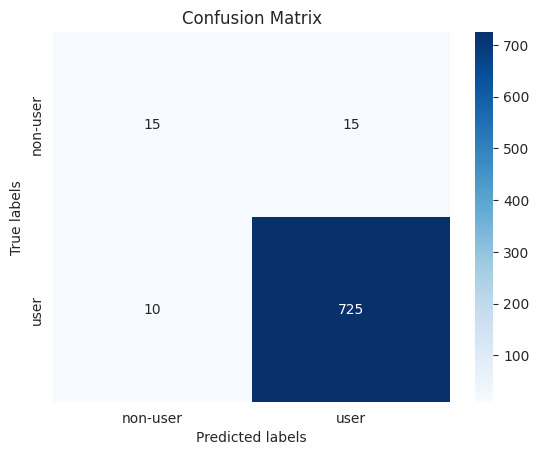

In [ ]:
plot_confusion_matrix(y_test, y_pred)

#Hybrid Model

In [ ]:
# Hybrid model using majority voting
from sklearn.ensemble import VotingClassifier


base_models = [
    ('Logistic Regression', LogisticRegression(C = 1, solver = 'lbfgs')),
    ('Support Vector Machines', SVC(C = 0.1, gamma = 'scale', kernel = 'linear')),
    ('Random Forest Classifier', RandomForestClassifier( max_depth =  None, min_samples_split = 2, n_estimators = 50)),
    ('AdaBoost Classifier', AdaBoostClassifier(learning_rate = 0.01, n_estimators =  50)),
    ('Decision Tree Classifier',  DecisionTreeClassifier(max_depth = 5, min_samples_split =  2))
]

#meta_learner = RidgeClassifier(alpha = 0.01)

hybrid_model = VotingClassifier(estimators= base_models, voting='hard')
hybrid_model.fit(X_train, y_train)
hybrid_acc = accuracy_score(y_test, hybrid_model.predict(X_test))
hybrid_f1 = f1_score(y_test, hybrid_model.predict(X_test), average='weighted')
hybrid_precision = precision_score(y_test, hybrid_model.predict(X_test), average='weighted')
hybrid_recall = recall_score(y_test, hybrid_model.predict(X_test), average='weighted')
print(f"Hybrid Model: Accuracy = {hybrid_acc:.2%}, F1-score = {hybrid_f1:.4f}, Precision = {hybrid_precision:.4f}, Recall = {hybrid_recall:.4f}")


Hybrid Model: Accuracy = 96.08%, F1-score = 0.9416, Precision = 0.9231, Recall = 0.9608


# Statistical anova

In [ ]:
import scipy.stats as stats

In [ ]:
# T-test: Comparing mean age of users vs non-users (assuming 'Cocaine_User' is binary: 0=No, 1=Yes)
alcohol_df['Age'] = pd.to_numeric(alcohol_df['Age'], errors='coerce') # Convert 'Age' to numeric, handling errors
users = alcohol_df[alcohol_df['Alcohol_User'] == 1]['Age']  # Use cocaine_df and 'Cocaine_User'
non_users = alcohol_df[alcohol_df['Alcohol_User'] == 0]['Age']  # Use cocaine_df and 'Cocaine_User'
# Import the scipy.stats module
from scipy import stats
t_stat, p_val = stats.ttest_ind(users, non_users, equal_var=False, nan_policy='omit') # Handle NaN values
print(f'Independent T-Test:\nt-statistic: {t_stat}, p-value: {p_val}')

Independent T-Test:
t-statistic: -3.831905392493437, p-value: 0.0002722256821426918


In [ ]:
# Collect accuracy scores
scores = {}
for name, (model_instance, _) in models.items():  # Unpack the tuple
    score = cross_val_score(model_instance, X_train, y_train, cv=5, scoring='accuracy')  # Use model_instance
    scores[name] = score

# Perform ANOVA test on model accuracy
anova_f, anova_p = stats.f_oneway(*scores.values())
print(f'ANOVA Test:\nF-statistic: {anova_f}, p-value: {anova_p}')

ANOVA Test:
F-statistic: 1.5511337276736368, p-value: 0.21179279703079004
